# **Model-free Prediction**

<hr>

### **Part 3**: Reinforcement Learning from Zero to One

*African Institute for Mathematical Sciences (AIMS), South Africa
4 March, 2026*

**Arnu Pretorius** - Staff Research Scientist, InstaDeep

<!--

Note: at this point, we are aware that starting with a deteministic policy is not the best, however, we also know that the optimal policy is a deterministic policy and after the first round of policy improvement, by using the greedy policy we will end up with a deterministic policy.

So, here we start with a deterministic policy and show that Monte Carlo Prediction does not work at all

Then, we will explain why, and then from here only use a stochastic (uniform) policy for the rest of the notebook.

Flow

* max_steps=50, N=10, num_episodes=100
* max_steps=50, N=10, num_episodes=1000

-->



## **The Numberline**

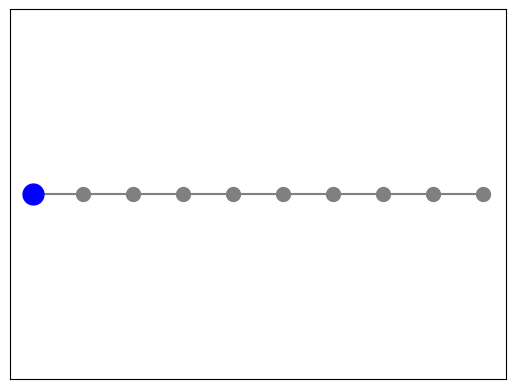

In [1]:
# @title Setup
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.animation as animation

class NumberLineEnv:
    def __init__(self, num_states=4, max_steps=50, move_probability=0.95, reward_type='sparse'):
        self.num_states = num_states
        self.max_steps = max_steps
        self.reward_state = self.num_states-1
        self.move_probability = move_probability
        self.reward_type = reward_type

    def reset(self, key):
        """Initialize the environment state."""
        state = (0, 0, key)
        timestep = (0, 0, False)
        return state, timestep

    def step(self, state, action):
        """Takes an action in the environment."""
        obs, step_count, key = state
        new_key, sub_key = jax.random.split(key)

        # Determine movement direction (intended or opposite)
        in_obsorbing_goal_state = obs == self.reward_state
        intended_direction = jnp.where(in_obsorbing_goal_state, 0, jnp.where(jax.random.uniform(sub_key) < self.move_probability, action, -1))

        # Update position based on stochastic action
        next_obs = jnp.clip(obs + intended_direction, 0, self.reward_state)

        # Calculate instantaneous reward
        is_at_goal = next_obs == self.reward_state
        reward = jax.lax.cond(
            self.reward_type == 'sparse',
            lambda x: jnp.where(x, 1, 0),
            lambda x: jnp.where(~x, -1, 0),
            is_at_goal,
        )
        done = (jnp.where(step_count == self.max_steps-1, 1, 0) + is_at_goal) > 0
        reward = jnp.where(in_obsorbing_goal_state, 0, reward)

        # Update state
        state = (next_obs, step_count + 1, new_key)
        timestep = (next_obs, reward, done)

        return state, timestep

    def _prepare_figure(self, ax):

        # Add labels and legend
        ax.set_xticks([])
        ax.set_yticks([])

    def _draw_state(self, ax, state):
        obs, _, _ = state

        # Create a line for the state space
        states = range(self.num_states)
        ax.plot(states, [0] * len(states), 'o-', color='gray', markersize=10)

        # Mark agent and target state
        ax.plot(self.num_states-1, 0)
        color = 'green' if obs == self.num_states - 1 else 'blue'
        ax.plot(obs, 0, 'o', color=color, markersize=15, label='Agent')


    def render(self, state):
        # Prepare figure and axis
        fig, ax = plt.subplots()
        ax.clear()
        self._prepare_figure(ax)

        # Mark the current state of the agent
        self._draw_state(ax, state)
        plt.show()

    def animate(self, states, interval=200, save_path=None):
        fig = plt.figure()
        fig.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0, hspace=0)
        ax = fig.add_subplot(111)
        plt.close(fig)
        self._prepare_figure(ax)

        def make_frame(state) -> None:
            ax.clear()
            self._prepare_figure(ax)
            self._draw_state(ax, state)

        # Create the animation object.
        self._animation = animation.FuncAnimation(
            fig,
            make_frame,
            frames=states,
            interval=interval,
        )

        # Save the animation as a gif.
        if save_path:
            self._animation.save(save_path)

        return self._animation


# policy helper functions
def make_deterministic_policy(fixed_key, probs=None):
    def policy(x, key=None):
        return jax.random.choice(fixed_key, jnp.array([-1, 1]), shape=(num_states,))[x]
    return policy

def make_stochastic_policy(burn_key, probs=None):
    if probs is None:
        probs = jnp.array([0.5, 0.5])
    def policy(x, key):
        key, sub_key = jax.random.split(key)
        return jax.random.choice(sub_key, jnp.array([-1, 1]), p=probs)
    return policy

def sample_policy(policy, key):
    keys = jax.random.split(key, num_states)
    return jnp.array([policy(x, key) for x, key in enumerate(keys)])

# create environment
num_states = 10
num_actions = 2
max_steps = 50
env = NumberLineEnv(num_states=num_states, max_steps=max_steps)
reset_fn = jax.jit(env.reset)
step_fn = jax.jit(env.step)

# visualise environment
key = jax.random.PRNGKey(3)
env_state, timestep = reset_fn(key)
env.render(env_state)

In [2]:
##########################################
# Change for different types of policies #
##########################################
# policy_fn = make_deterministic_policy
policy_fn = make_stochastic_policy

key, sample_key, policy_key = jax.random.split(key, 3)
policy = policy_fn(policy_key)

# sample policy
sample_policy(policy, sample_key)

Array([ 1, -1,  1,  1,  1, -1,  1,  1, -1,  1], dtype=int32)

### From previous lecture: $v_{\pi_0}$ using Dynammic Programming

In [3]:
V1_dp = jnp.array([0.01823676, 0.0225207, 0.0325425, 0.05124729, 0.08392677, 0.13969061, 0.23401532, 0.3930175, 0.6606995,  0.])
V1_dp

Array([0.01823676, 0.0225207 , 0.0325425 , 0.05124729, 0.08392677,
       0.13969061, 0.23401532, 0.3930175 , 0.6606995 , 0.        ],      dtype=float32)

## **Monte Carlo prediction**

### Incremental Monte-Carlo
Update value $V(S_t)$ toward the return $G_t$ $$ V(S_t) \leftarrow V(S_t) +  (G_t - V(S_t)) / N(S_t) $$




In [4]:
# parameters
num_episodes = 1000
gamma = 0.9

# empty tables
key_init = jax.random.PRNGKey(0)
N_init = jnp.zeros(num_states)
V_init = jnp.zeros(num_states)

In [5]:
def scan_rollout_step_fn(state, unused_t):
    env_state, _ = state
    obs, _, key = env_state
    action = policy(obs, key)
    state = step_fn(env_state, action)
    append = (obs, state[1][1], state[1][2])
    return state, (append)

def rollout_episode_fn(key):
    initial_state = reset_fn(key)
    _, (trajectory) = jax.lax.scan(scan_rollout_step_fn, initial_state, jnp.arange(max_steps))

    return jnp.array(trajectory)

batched_rollout_fn = jax.jit(jax.vmap(rollout_episode_fn))

In [6]:
def scan_step_fn(state, timestep):
    G, N, V, in_episode = state
    obs, reward, done = timestep[0], timestep[1], timestep[2]

    G = gamma * G * (1-done) + reward

    eoe_ms = done * (1-reward) * (obs < num_states - 1)
    eoe_r = G > 0
    moe = (1-done) * (obs < num_states - 1)
    in_episode = jnp.where(eoe_ms + eoe_r + moe, 1, 0)

    N = N.at[obs].add(in_episode)
    V = V.at[obs].set(V[obs] + in_episode*(G - V[obs]) / (1-in_episode + N[obs]))
    return (G, N, V, in_episode), (G)

def mc_prediction(key, N, V):
    keys = jax.random.split(jax.random.PRNGKey(0), num_episodes)
    trajectories = batched_rollout_fn(keys).transpose(0, 2, 1).reshape((-1, 3))

    initial_state = (0, N, V, 1)
    (_, N, V, _), G_hist = jax.lax.scan(scan_step_fn, initial_state, trajectories, reverse=True)
    return V, G_hist

mc_prediction_fn = jax.jit(mc_prediction)

In [7]:
# Run JAXified Monte Carlo prediction
V_pi_mc, G_hist = mc_prediction_fn(key_init, N_init, V_init)
V_pi_mc.block_until_ready()

Array([0.02067588, 0.02378585, 0.03377201, 0.052688  , 0.0839504 ,
       0.13564727, 0.22319934, 0.37970012, 0.66298735, 0.        ],      dtype=float32)


## **Temporal-difference learning**

*General* update rule
    $$ V(S_t) \leftarrow V(S_t) + \alpha (U_t - V(S_t)) $$
* **Monte-Carlo**: $U_t = G_t$
    

* **Temporal-difference**: $U_t = R_{t+1} + \gamma V(S_{t+1})$

### Incremental TD(0)
Update value $V(S_t)$ toward the *bootstrapped* return $R_{t+1} + \gamma V(S_{t+1})$, using step size $\alpha$: $$ V(S_t) \leftarrow V(S_t) +  α(R_{t+1} + \gamma V(S_{t+1}) - V(S_t)) $$
    

In [14]:
def scan_step_fn(state, unused_t):
    V, env_state = state
    obs, _, key = env_state
    action = policy(obs, key)
    env_state, timestep = step_fn(env_state, action)

    next_obs, reward, done = timestep
    TD_target = gamma * V[next_obs] + reward
    V = V.at[obs].set(V[obs] + alpha*(TD_target - V[obs]))
    return (V, env_state), (TD_target)

def scan_episode_fn(state, unused_t):
    key, V = state
    key, reset_key, policy_key = jax.random.split(key, 3)
    initial_env_state, _ = reset_fn(reset_key)

    initial_state = (V, initial_env_state)
    (V, _), target_hist = jax.lax.scan(scan_step_fn, initial_state, jnp.arange(max_steps))
    return (key, V), (target_hist)

def td_prediction(key, V):
    initial_state = (key, V)
    (_, V), target_hist = jax.lax.scan(scan_episode_fn, initial_state, jnp.arange(num_episodes))
    return V, target_hist

td_prediction_fn = jax.jit(td_prediction)

In [15]:
# TD parameter
alpha=0.1

# Run the TD prediction
V_pi_td, target_hist = td_prediction_fn(key_init, V_init)
V_pi_td

Array([0.02951206, 0.03540604, 0.04727794, 0.07385001, 0.11949812,
       0.1800231 , 0.26403236, 0.41395134, 0.72505283, 0.        ],      dtype=float32)

## Bias / variance trade-off


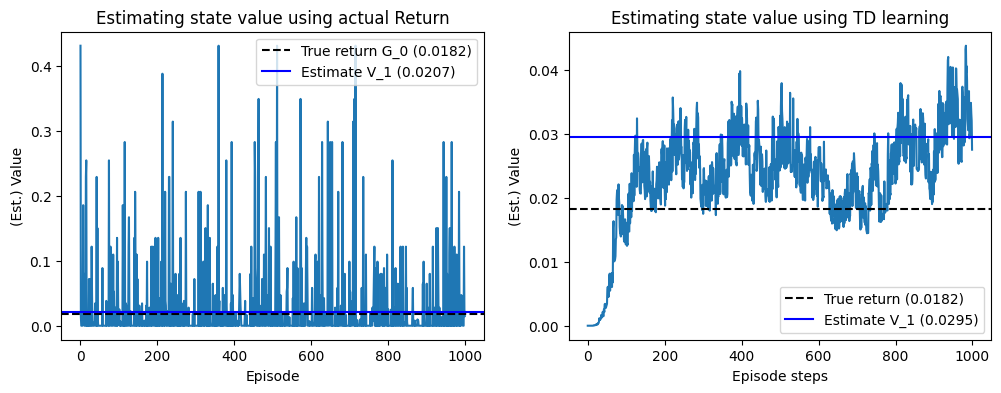

In [16]:
G_hist_state_0 = G_hist[::max_steps]
target_hist_state_0 = target_hist.ravel()[::max_steps]

mean_return = jnp.mean(G_hist_state_0)
var_return = jnp.var(G_hist_state_0)
mean_td_target = jnp.mean(target_hist_state_0)
var_td_target = jnp.var(target_hist_state_0)

plt.figure(figsize=(12, 4))

# Monte Carlo
plt.subplot(1, 2, 1)
plt.plot(G_hist_state_0)
plt.axhline(y=V1_dp[0], color='black', linestyle='--', label=f'True return G_0 ({V1_dp[0]:.4f})')
plt.axhline(y=V_pi_mc[0], color='blue', linestyle='-', label=f'Estimate V_1 ({V_pi_mc[0]:.4f})')
plt.legend()
plt.title("Estimating state value using actual Return")
plt.xlabel("Episode")
plt.ylabel("(Est.) Value")

# TD(0)
plt.subplot(1, 2, 2)
plt.plot(target_hist_state_0)
plt.axhline(y=V1_dp[0], color='black', linestyle='--', label=f'True return ({V1_dp[0]:.4f})')
plt.axhline(y=V_pi_td[0], color='blue', linestyle='-', label=f'Estimate V_1 ({V_pi_td[0]:.4f})')
plt.legend()
plt.title("Estimating state value using TD learning")
plt.xlabel("Episode steps")
plt.ylabel("(Est.) Value")

plt.show()